# Named Entity Recognition (NER) with spaCy

## Step 1: Load Data

In [1]:
# Import libraries
import numpy as np
import pandas as pd
from plotnine import *
import warnings
warnings.filterwarnings('ignore')

# Use sklearn for dataset
from sklearn.datasets import fetch_20newsgroups

# Import spaCy for NER
import spacy
from collections import Counter

# Set random seed for reproducibility
np.random.seed(42)

In [2]:
# Load a subset of the 20 newsgroups dataset (3 categories)
categories = [
    'rec.sport.baseball',
    'talk.politics.guns',
    'sci.space'
]

# Fetch the dataset, removing headers/footers/quotes for cleaner text
newsgroups = fetch_20newsgroups(
    subset='all',
    categories=categories,
    remove=('headers', 'footers', 'quotes'),
    random_state=42
)

# Extract documents and create labels mapping
documents = newsgroups.data
category_names = newsgroups.target_names

# Check results
print(f"Number of documents: {len(documents)}")
print(f"Categories: {category_names}")
print(f"\nSample document:\n{documents[0][:250]}...")

Number of documents: 2891
Categories: ['rec.sport.baseball', 'sci.space', 'talk.politics.guns']

Sample document:

This activity is regularly reported in Ron's interesting posts. Could
someone explain what the Command Loss Timer is?

Thanks, Alan...


## Step 2: Load spaCy Model

In [3]:
# Load spaCy's pre-trained English model for NER
# This model has been trained on OntoNotes 5 and can recognize multiple entity types
# If not installed, run: python -m spacy download en_core_web_sm
nlp = spacy.load('en_core_web_sm')

# Display available entity types
print("Available entity types:")
print(", ".join(nlp.pipe_labels['ner']))

Available entity types:
CARDINAL, DATE, EVENT, FAC, GPE, LANGUAGE, LAW, LOC, MONEY, NORP, ORDINAL, ORG, PERCENT, PERSON, PRODUCT, QUANTITY, TIME, WORK_OF_ART


## Step 3: Perform Named Entity Recognition

In [4]:
def extract_entities(
    documents: list,
    nlp: spacy.language.Language,
    max_docs: int = 100
) -> pd.DataFrame:
    """
    Extract named entities from a list of documents using spaCy.
    Process documents through the SpaCy NER pipeline.
    Extract all recognized entities with types and source document info.
    
    Parameters:
    documents (list): List of text documents to process.
    nlp (spacy.language.Language): Loaded spaCy language model with NER pipeline.
    max_docs (int): Maximum number of documents to process (default: 100).
    
    Returns:
    pd.DataFrame: DataFrame containing columns for entity text, type, and document index.
    """
    entities = []
    
    # Process a subset of documents to keep runtime reasonable
    for doc_idx, doc_text in enumerate(documents[:max_docs]):
        # Apply spaCy NER pipeline to the document
        doc = nlp(doc_text)
        
        # Extract each entity found in the document
        for ent in doc.ents:
            entities.append({
                'text': ent.text,
                'label': ent.label_,
                'doc_idx': doc_idx
            })
    
    # Convert to DataFrame for easier analysis
    return pd.DataFrame(entities)

# Extract entities from documents
print("Extracting entities from documents...")
entities_df = extract_entities(documents, nlp, max_docs=200)

# Check results
print(f"\nTotal entities extracted: {len(entities_df)}")
print(f"Unique entity types: {entities_df['label'].nunique()}")
print(f"\nFirst few entities:")
print(entities_df.head(10))

Extracting entities from documents...

Total entities extracted: 3495
Unique entity types: 18

First few entities:
            text     label  doc_idx
0            Ron    PERSON        0
1           Alan    PERSON        0
2  Ali AbuTaha's    PERSON        1
3             57  CARDINAL        1
4     Challenger       ORG        1
5            SRB       ORG        1
6          Roger    PERSON        2
7       Canadian      NORP        2
8           1988      DATE        2
9      Bob Errey    PERSON        2


## Step 4: Examine Entity Distributions

In [5]:
def display_entity_stats(
    entities_df: pd.DataFrame,
    n_top: int = 10
) -> None:
    """
    Display statistics about extracted entities including counts and examples.
    
    Parameters:
    entities_df (pd.DataFrame): DataFrame containing extracted entities with 'text' and 'label' columns.
    n_top (int): Number of top examples to display per entity type (default: 10).
    
    Returns:
    None: Prints entity statistics to stdout.
    """
    # Count entities by type
    entity_counts = entities_df['label'].value_counts()
    
    print("ENTITY TYPE DISTRIBUTION:")
    print(entity_counts)
    
    # Show examples for each entity type
    print("\n" + "="*60)
    print("EXAMPLES BY ENTITY TYPE:")
    print("="*60)
    
    for label in entity_counts.index:
        # Get top entities of this type by frequency
        label_entities = entities_df[entities_df['label'] == label]['text']
        top_entities = label_entities.value_counts().head(n_top)
        
        print(f"\n{label}:")
        for entity, count in top_entities.items():
            print(f"  {entity} ({count})")

# Display entity statistics
display_entity_stats(entities_df, n_top=10)

ENTITY TYPE DISTRIBUTION:
label
ORG            752
CARDINAL       729
PERSON         566
DATE           378
GPE            251
LOC            173
QUANTITY       146
NORP           110
ORDINAL        102
PRODUCT         96
MONEY           43
TIME            43
WORK_OF_ART     36
FAC             23
PERCENT         18
EVENT           14
LAW             12
LANGUAGE         3
Name: count, dtype: int64

EXAMPLES BY ENTITY TYPE:

ORG:
  NASA (31)
  FBI (30)
  Sun (24)
  Mercury (23)
  Venus (20)
  Neptune (16)
  ATF (16)
  Mariner (14)
  RRA (10)
  Larson (10)

CARDINAL:
  1 (52)
  one (40)
  two (36)
  2 (31)
  0 (29)
  5 (26)
  3 (21)
  4 (16)
  6 (16)
  three (12)

PERSON:
  Moon (27)
  Olson (9)
  Fred (8)
  Clinton (7)
  Pluto (4)
  David Koresh (4)
  Dennis (4)
  Carter (4)
  Lankford (4)
  Saturn (4)

DATE:
  today (12)
  last year (10)
  1992 (9)
  1979 (5)
  1984 (5)
  1988 (4)
  this year (4)
  annual (4)
  1959 (4)
  1990 (4)

GPE:
  Seattle (21)
  Vancouver (16)
  US (10)
  UK (8)

## Step 5: Visualize Entity Distributions

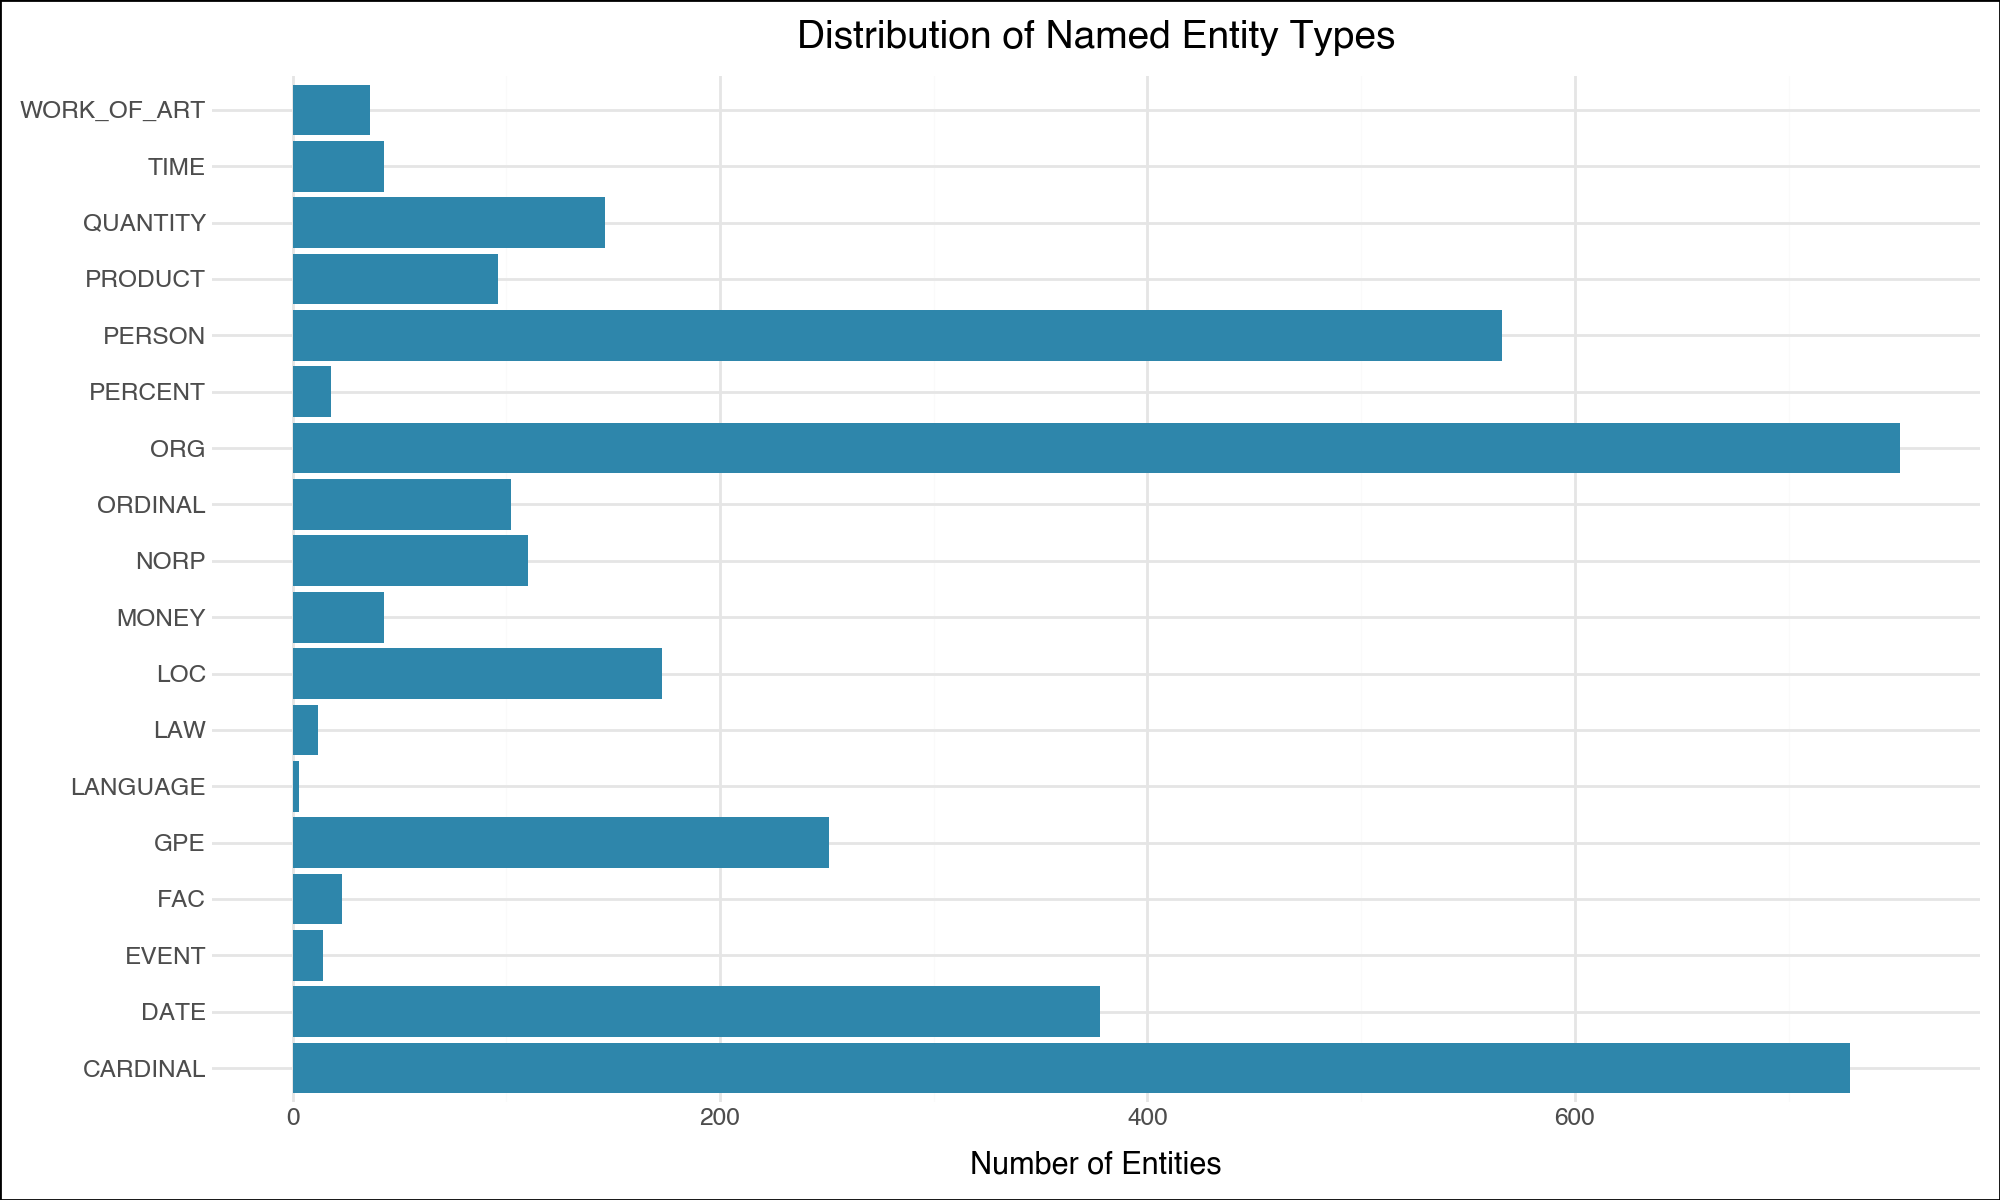

In [8]:
# Create a bar chart showing entity type distribution
entity_counts = entities_df['label'].value_counts().reset_index()
entity_counts.columns = ['Entity_Type', 'Count']

# Create bar plot
plot = (
    ggplot(entity_counts, aes(x='Entity_Type', y='Count'))
    + geom_bar(stat='identity', fill='#2E86AB')
    + coord_flip()
    + labs(
        title='Distribution of Named Entity Types',
        x='',
        y='Number of Entities'
    )
    + theme_minimal()
    + theme(
        figure_size=(10, 6),
        plot_title=element_text(size=14, weight='bold'),
        plot_background=element_rect(fill='white'),
        panel_background=element_rect(fill='white')
    )
)

# Display plot
display(plot)

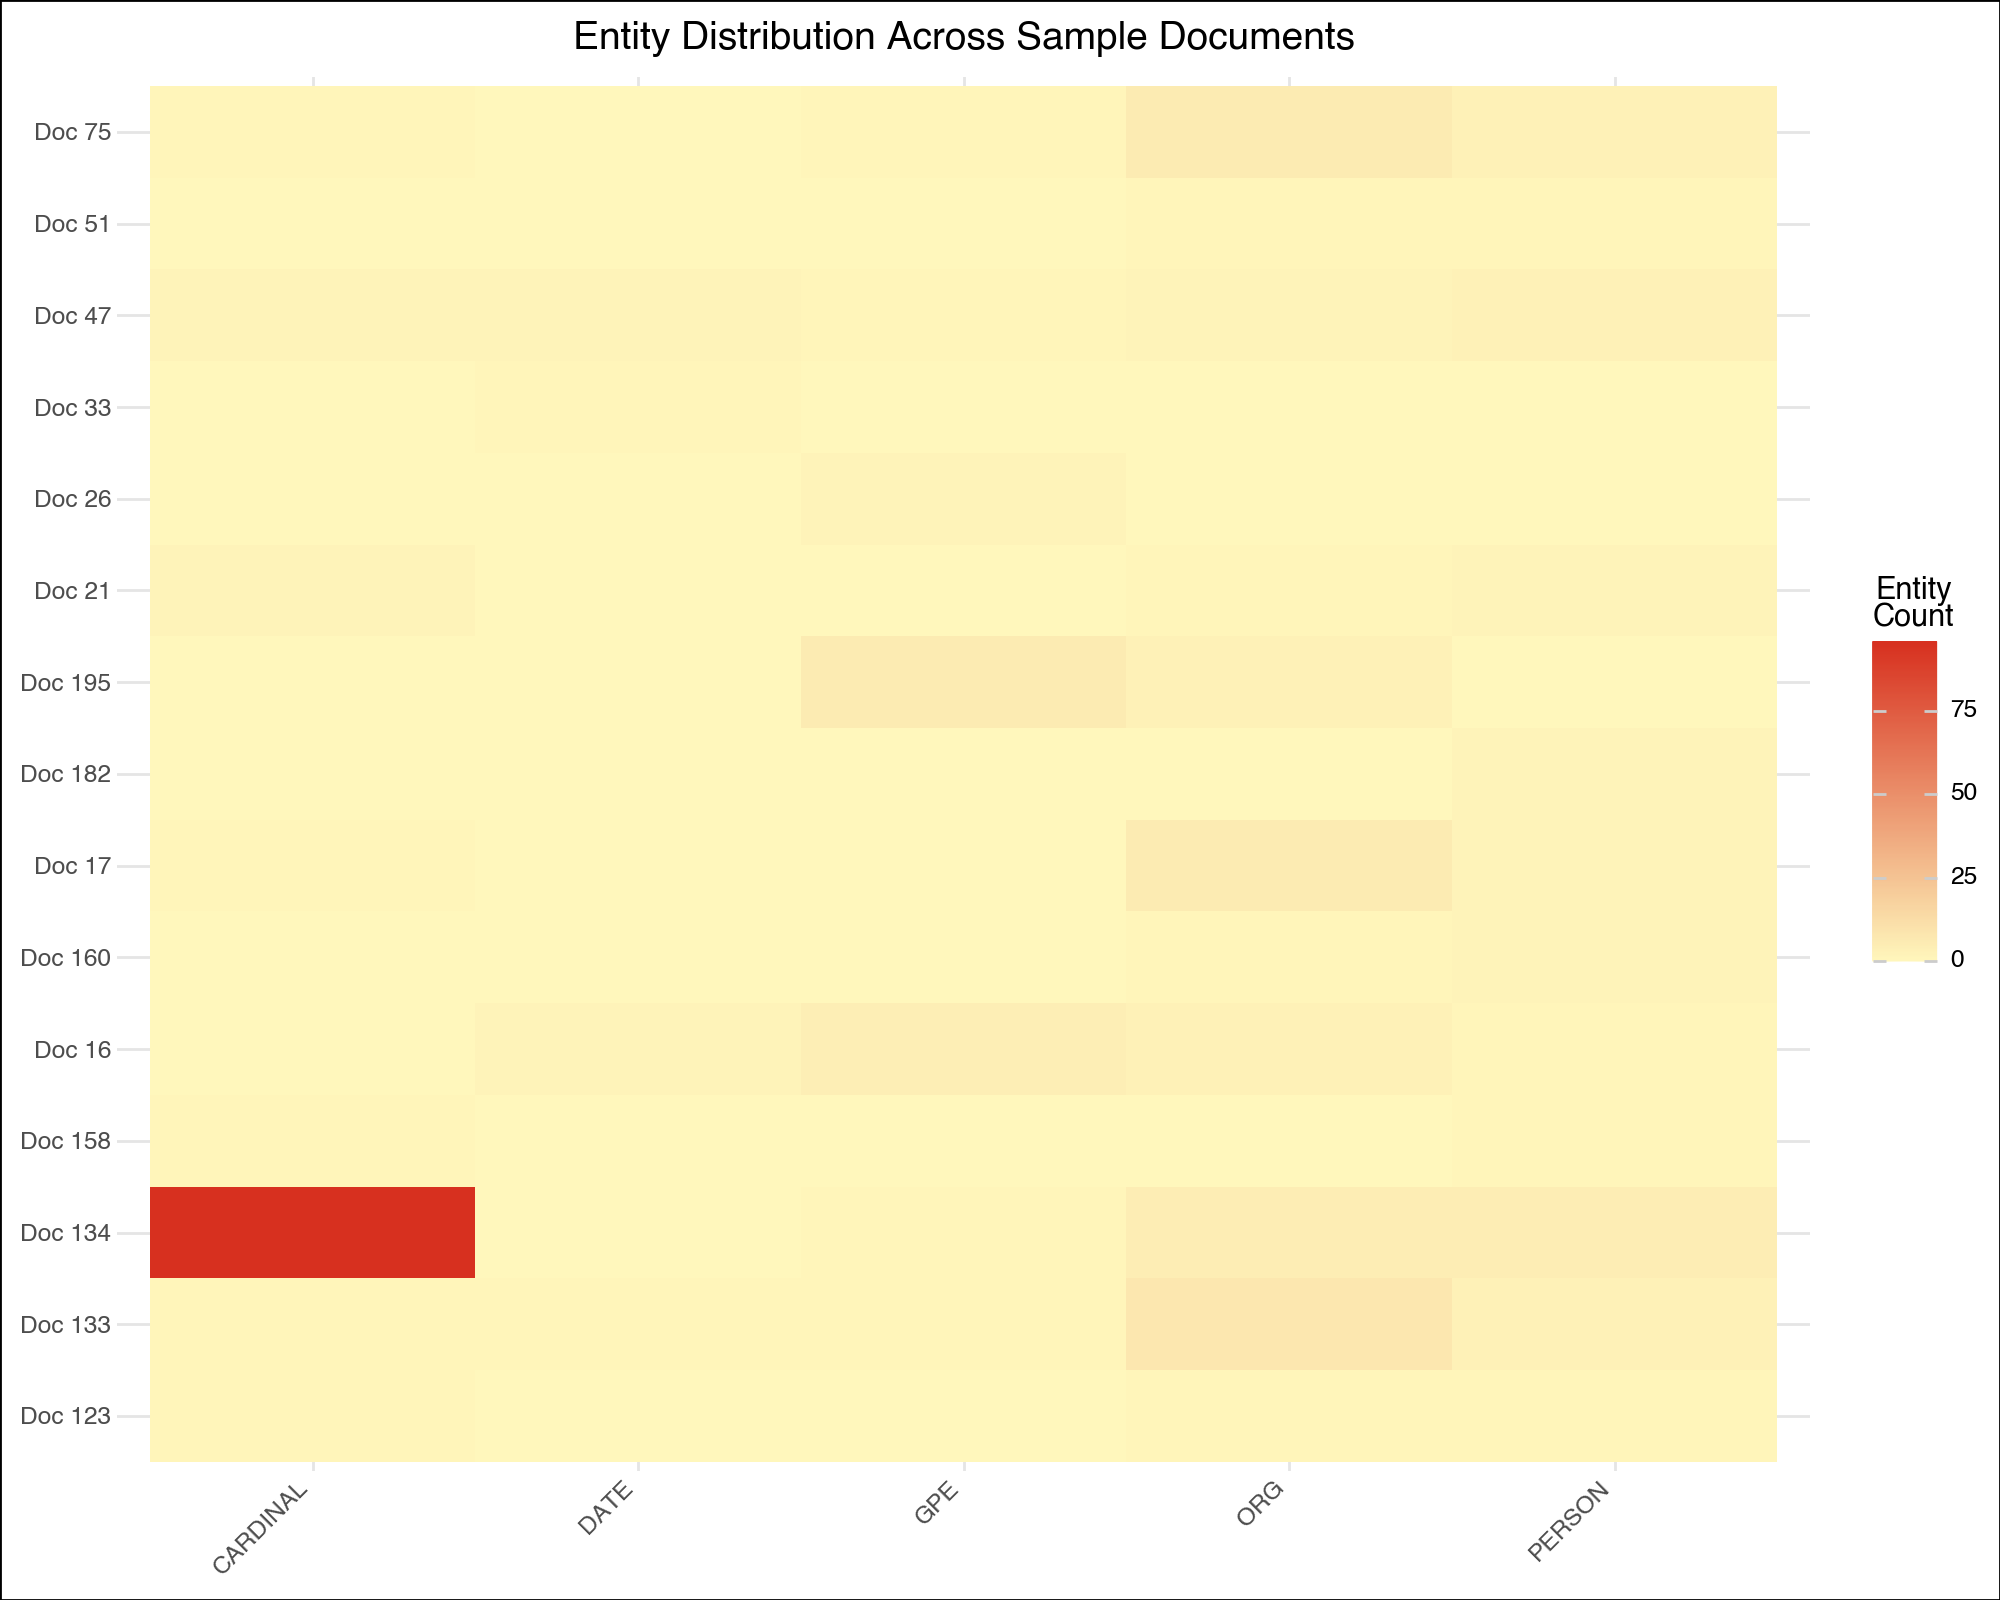

In [9]:
# Create a heatmap showing entity distribution across documents
# Select top entity types for visualization
top_entity_types = entities_df['label'].value_counts().head(5).index.tolist()

# Sample documents for visualization
n_docs_to_show = 15
doc_indices = np.random.choice(entities_df['doc_idx'].unique(), 
                               min(n_docs_to_show, entities_df['doc_idx'].nunique()), 
                               replace=False)

# Create document-entity matrix
heatmap_data = []
for doc_idx in doc_indices:
    doc_entities = entities_df[entities_df['doc_idx'] == doc_idx]
    entity_counts_by_type = doc_entities['label'].value_counts()
    
    row = {'Document': f'Doc {doc_idx}'}
    for entity_type in top_entity_types:
        row[entity_type] = entity_counts_by_type.get(entity_type, 0)
    heatmap_data.append(row)

heatmap_df = pd.DataFrame(heatmap_data)
heatmap_long = heatmap_df.melt(
    id_vars='Document',
    var_name='Entity_Type',
    value_name='Count'
)

# Create heatmap using geom_tile
plot = (
    ggplot(heatmap_long, aes(x='Entity_Type', y='Document', fill='Count'))
    + geom_tile()
    + scale_fill_gradient(low='#FFF7BC', high='#D7301F', name='Entity\nCount')
    + labs(
        title='Entity Distribution Across Sample Documents',
        x='',
        y=''
    )
    + theme_minimal()
    + theme(
        figure_size=(10, 8),
        axis_text_x=element_text(rotation=45, hjust=1),
        plot_title=element_text(size=14, weight='bold'),
        plot_background=element_rect(fill='white'),
        panel_background=element_rect(fill='white')
    )
)

# Display plot
display(plot)